# 🔬 Cancer Detection – Model Testing Notebook
**Vision Transformer / ResNet18 | Chest X-Ray (Pneumonia vs Normal)**

This notebook covers:
1. Setup & Imports
2. Load Trained Model
3. Dataset Evaluation (Test Set Accuracy & Loss)
4. Confusion Matrix & Classification Report
5. Per-Class Metrics (Precision, Recall, F1)
6. Single Image Prediction
7. GradCAM Explainability Visualization

---
## ⚙️ 1. Setup & Imports

In [2]:
# %pip install seaborn



In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_recall_fscore_support
)
from PIL import Image

# ── reproducibility ──
torch.manual_seed(42)
np.random.seed(42)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'✅ Using device: {device}')
if device == 'cuda':
    print(f'   GPU: {torch.cuda.get_device_name(0)}')

✅ Using device: cpu


---
## 🗂️ 2. Load Trained Model

In [4]:
# ── Paths ──────────────────────────────────────────────────────────────────────
MODEL_PATH    = r'../models/xray_model.pth'          # saved by train.py
TEST_DATA_DIR = r'../Data/chest_xray/chest_xray/test'
TRAIN_DATA_DIR = r'../Data/chest_xray/chest_xray/train'

NUM_CLASSES  = 2
CLASS_NAMES  = ['NORMAL', 'PNEUMONIA']   # ImageFolder alphabetical order

# ── Transforms (same as training) ─────────────────────────────────────────────
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ── Build Model Architecture ───────────────────────────────────────────────────
model = models.resnet18(weights=None)           # no pretrained download needed
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
model = model.to(device)

# ── Load Weights ───────────────────────────────────────────────────────────────
if os.path.exists(MODEL_PATH):
    state_dict = torch.load(MODEL_PATH, map_location=device)
    model.load_state_dict(state_dict)
    model.eval()
    print(f'✅ Model loaded from: {MODEL_PATH}')
else:
    print(f'❌ ERROR: Model file not found at "{MODEL_PATH}"')
    print('   Run Backend/train.py first to train and save the model.')

✅ Model loaded from: ../models/xray_model.pth


---
## 📊 3. Dataset Evaluation – Test Set Accuracy & Loss

In [5]:
test_dataset = datasets.ImageFolder(TEST_DATA_DIR, transform=transform)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

print(f'📂 Test Dataset: {len(test_dataset)} images')
print(f'   Classes: {test_dataset.classes}')
print(f'   Class-to-index: {test_dataset.class_to_idx}')

criterion = nn.CrossEntropyLoss()

all_preds  = []
all_labels = []
all_probs  = []
total_loss = 0.0

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss    = criterion(outputs, labels)
        total_loss += loss.item() * images.size(0)

        probs  = F.softmax(outputs, dim=1)
        preds  = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

avg_loss = total_loss / len(test_dataset)
accuracy = accuracy_score(all_labels, all_preds) * 100

print(f'\n📈 Test Results')
print(f'   Loss    : {avg_loss:.4f}')
print(f'   Accuracy: {accuracy:.2f}%')

📂 Test Dataset: 624 images
   Classes: ['NORMAL', 'PNEUMONIA']
   Class-to-index: {'NORMAL': 0, 'PNEUMONIA': 1}

📈 Test Results
   Loss    : 0.3852
   Accuracy: 87.50%


---
## 🧩 4. Confusion Matrix

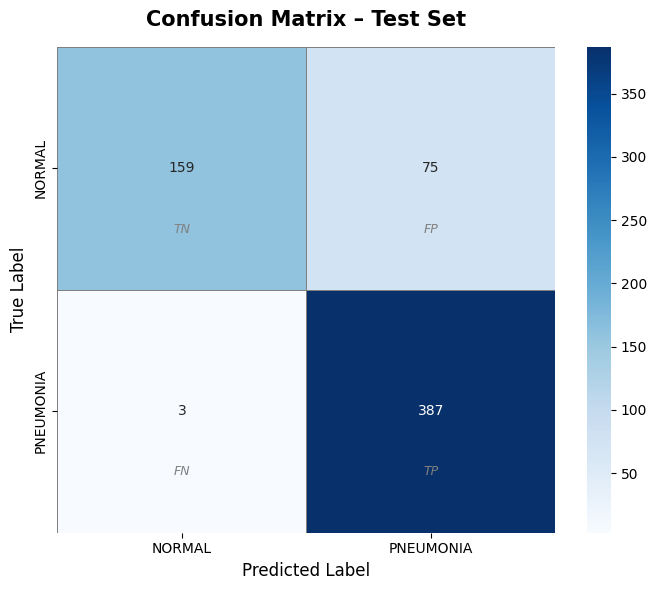

💾 Saved: reports/confusion_matrix.png


In [ ]:
cm = confusion_matrix(all_labels, all_preds)
    
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    linewidths=0.5, linecolor='gray',
    ax=ax
)
ax.set_title('Confusion Matrix – Test Set', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)

# Annotate TN / FP / FN / TP
labels_box = [['TN', 'FP'], ['FN', 'TP']]
for i in range(2):
    for j in range(2):
        ax.text(j + 0.5, i + 0.75, labels_box[i][j],
                ha='center', va='center', fontsize=9,
                color='gray', style='italic')

plt.tight_layout()
plt.savefig('../reports/confusion_matrix.png', dpi=150)
plt.show()
print('💾 Saved: reports/confusion_matrix.png')

---
## 📋 5. Classification Report & Per-Class Metrics

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.98      0.68      0.80       234
   PNEUMONIA       0.84      0.99      0.91       390

    accuracy                           0.88       624
   macro avg       0.91      0.84      0.86       624
weighted avg       0.89      0.88      0.87       624



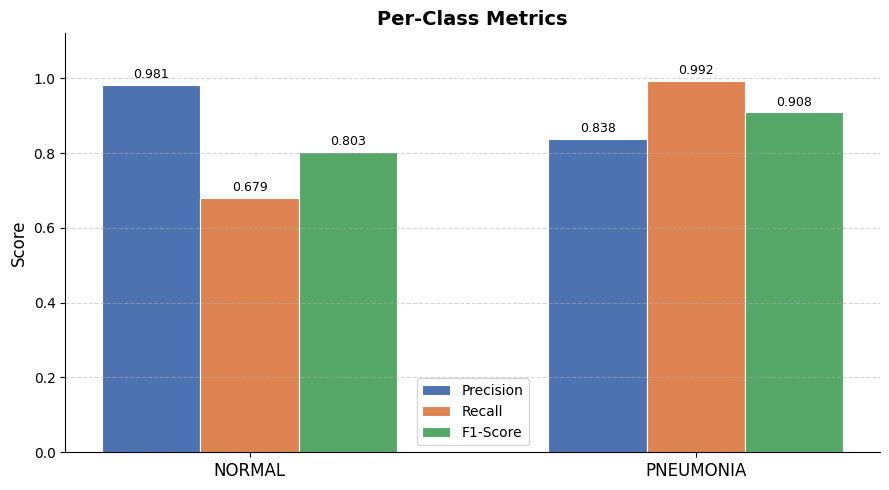

💾 Saved: reports/per_class_metrics.png


In [7]:
report = classification_report(all_labels, all_preds,
                                target_names=CLASS_NAMES)
print('Classification Report:')
print('=' * 55)
print(report)

precision, recall, f1, support = precision_recall_fscore_support(
    all_labels, all_preds, labels=[0, 1]
)

# ── Bar Chart ─────────────────────────────────────────────────────────────────
metrics_df = {
    'Precision': precision,
    'Recall'   : recall,
    'F1-Score' : f1
}
x = np.arange(len(CLASS_NAMES))
width = 0.22
colors = ['#4C72B0', '#DD8452', '#55A868']

fig, ax = plt.subplots(figsize=(9, 5))
for idx, (metric_name, values) in enumerate(metrics_df.items()):
    bars = ax.bar(x + (idx - 1) * width, values, width,
                  label=metric_name, color=colors[idx], edgecolor='white', linewidth=0.8)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_ylim(0, 1.12)
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Per-Class Metrics', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../reports/per_class_metrics.png', dpi=150)
plt.show()
print('💾 Saved: reports/per_class_metrics.png')

---
## 🤔 6. Sample Predictions from Test Set

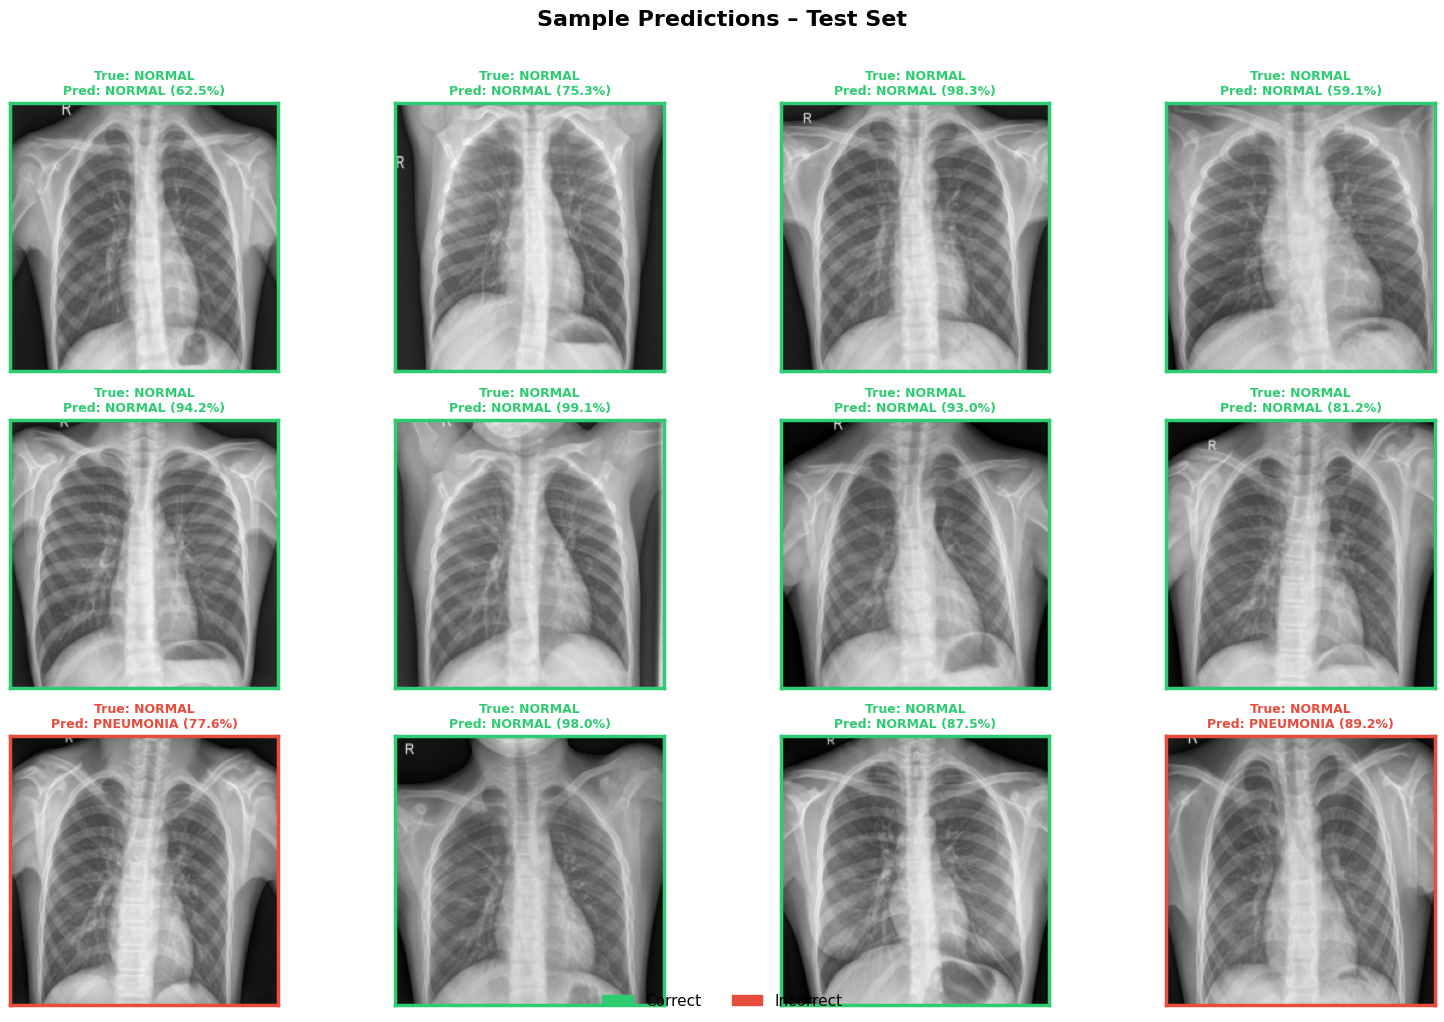

💾 Saved: reports/sample_predictions.png


In [8]:
def show_sample_predictions(loader, n=12):
    images_shown = 0
    fig, axes = plt.subplots(3, 4, figsize=(16, 10))
    axes = axes.flatten()

    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])

    model.eval()
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            outputs = model(imgs)
            probs   = F.softmax(outputs, dim=1)
            preds   = torch.argmax(probs, dim=1)

            for i in range(imgs.size(0)):
                if images_shown >= n:
                    break
                # Un-normalize for display
                img_np = imgs[i].cpu().numpy().transpose(1, 2, 0)
                img_np = np.clip(img_np * std + mean, 0, 1)

                true_label = CLASS_NAMES[lbls[i].item()]
                pred_label = CLASS_NAMES[preds[i].item()]
                conf       = probs[i][preds[i]].item() * 100
                correct    = (lbls[i] == preds[i]).item()

                ax = axes[images_shown]
                ax.imshow(img_np, cmap='gray' if img_np.shape[2] == 1 else None)
                color = '#2ecc71' if correct else '#e74c3c'
                ax.set_title(
                    f'True: {true_label}\nPred: {pred_label} ({conf:.1f}%)',
                    fontsize=9, color=color, fontweight='bold'
                )
                ax.set_xticks([])
                ax.set_yticks([])
                for spine in ax.spines.values():
                    spine.set_edgecolor(color)
                    spine.set_linewidth(2.5)

                images_shown += 1
            if images_shown >= n:
                break

    # Legend
    correct_patch   = mpatches.Patch(color='#2ecc71', label='Correct')
    incorrect_patch = mpatches.Patch(color='#e74c3c', label='Incorrect')
    fig.legend(handles=[correct_patch, incorrect_patch],
               loc='lower center', ncol=2, fontsize=11, frameon=False)
    fig.suptitle('Sample Predictions – Test Set', fontsize=16, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('../reports/sample_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('💾 Saved: reports/sample_predictions.png')

show_sample_predictions(test_loader, n=12)

---
## 🖼️ 7. Single Image Prediction

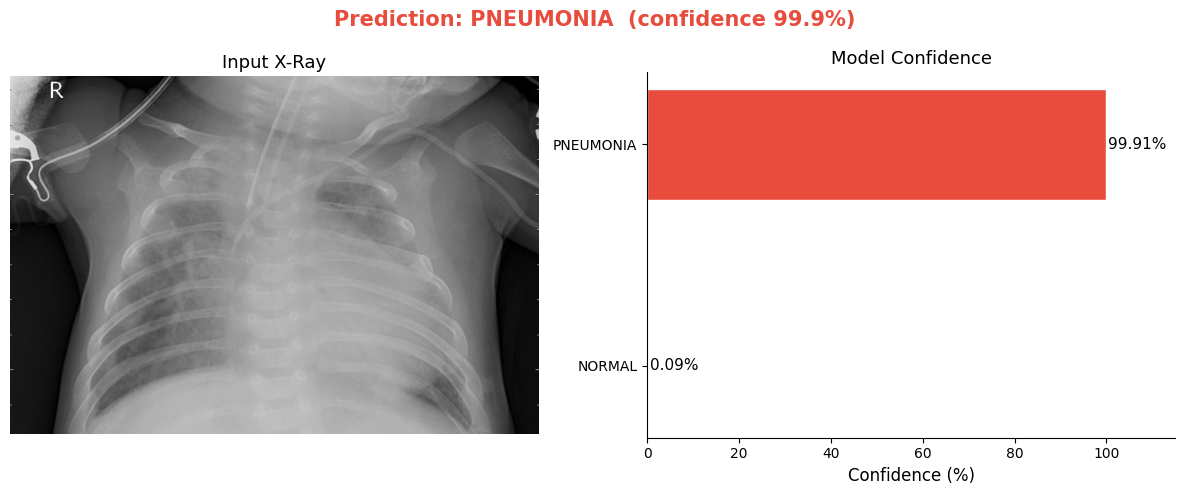

Result → PNEUMONIA
   NORMAL: 0.09%
   PNEUMONIA: 99.91%


In [9]:
def predict_single_image(image_path: str):
    """Predict a single X-ray image and display confidence scores."""
    infer_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

    img_pil = Image.open(image_path).convert('RGB')
    tensor  = infer_transform(img_pil).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(tensor)
        probs  = F.softmax(output, dim=1)[0].cpu().numpy()
        pred   = np.argmax(probs)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Left – image
    axes[0].imshow(img_pil, cmap='gray')
    axes[0].set_title(f'Input X-Ray', fontsize=13)
    axes[0].axis('off')

    # Right – confidence bar
    bar_colors = ['#3498db' if i != pred else '#e74c3c' for i in range(NUM_CLASSES)]
    bars = axes[1].barh(CLASS_NAMES, probs * 100, color=bar_colors, edgecolor='white', height=0.5)
    for bar, p in zip(bars, probs):
        axes[1].text(p * 100 + 0.5, bar.get_y() + bar.get_height() / 2,
                     f'{p * 100:.2f}%', va='center', fontsize=11)
    axes[1].set_xlim(0, 115)
    axes[1].set_xlabel('Confidence (%)', fontsize=12)
    axes[1].set_title('Model Confidence', fontsize=13)
    axes[1].spines['top'].set_visible(False)
    axes[1].spines['right'].set_visible(False)

    result = CLASS_NAMES[pred]
    fig.suptitle(f'Prediction: {result}  (confidence {probs[pred]*100:.1f}%)',
                 fontsize=15, fontweight='bold',
                 color='#e74c3c' if result == 'PNEUMONIA' else '#2ecc71')
    plt.tight_layout()
    plt.show()
    return result, probs

# ── Example: pick any image from the test set ─────────────────────────────────
# Change this path to any chest X-ray image you want to test
SAMPLE_IMAGE = r'../Data/chest_xray/chest_xray/test/PNEUMONIA/person1_virus_6.jpeg'

if os.path.exists(SAMPLE_IMAGE):
    label, probabilities = predict_single_image(SAMPLE_IMAGE)
    print(f'Result → {label}')
    for cls, p in zip(CLASS_NAMES, probabilities):
        print(f'   {cls}: {p*100:.2f}%')
else:
    # Auto-pick the first image in test/PNEUMONIA
    base = r'../Data/chest_xray/chest_xray/test/PNEUMONIA'
    imgs = [f for f in os.listdir(base) if f.lower().endswith(('.jpeg', '.jpg', '.png'))]
    if imgs:
        label, probabilities = predict_single_image(os.path.join(base, imgs[0]))
        print(f'Result → {label}  ({imgs[0]})')
    else:
        print('⚠️ No test images found – update SAMPLE_IMAGE path')

---
## 🔍 8. GradCAM – Explainability Heatmap

In [10]:
import cv2

class GradCAM:
    """Gradient-weighted Class Activation Mapping for ResNet."""

    def __init__(self, model, target_layer):
        self.model        = model
        self.target_layer = target_layer
        self.gradients    = None
        self.activations  = None
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, inp, out):
            self.activations = out.detach()

        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        output = self.model(input_tensor)

        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()
        one_hot = torch.zeros_like(output)
        one_hot[0][class_idx] = 1.0
        output.backward(gradient=one_hot)

        # Pool gradients across spatial dims
        weights  = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam      = (weights * self.activations).sum(dim=1, keepdim=True)
        cam      = F.relu(cam)
        cam      = cam.squeeze().cpu().numpy()
        cam      = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, class_idx


def show_gradcam(image_path: str, class_idx: int = None):
    infer_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])

    img_pil    = Image.open(image_path).convert('RGB')
    img_tensor = infer_transform(img_pil).unsqueeze(0).to(device)
    img_tensor.requires_grad_(True)

    gradcam = GradCAM(model, model.layer4[-1])
    cam, pred_idx = gradcam.generate(img_tensor, class_idx)

    # Overlay
    img_np   = np.array(img_pil.resize((224, 224))) / 255.0
    heatmap  = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap  = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
    overlay  = 0.5 * img_np + 0.4 * heatmap
    overlay  = np.clip(overlay, 0, 1)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    titles = ['Original X-Ray', 'GradCAM Heatmap', 'Overlay']
    images = [img_np, heatmap, overlay]
    for ax, title, im in zip(axes, titles, images):
        ax.imshow(im)
        ax.set_title(title, fontsize=13, fontweight='bold')
        ax.axis('off')

    fig.suptitle(
        f'GradCAM – Predicted: {CLASS_NAMES[pred_idx]}',
        fontsize=15, fontweight='bold',
        color='#e74c3c' if CLASS_NAMES[pred_idx] == 'PNEUMONIA' else '#27ae60'
    )
    plt.tight_layout()
    plt.savefig('../reports/gradcam_output.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('💾 Saved: reports/gradcam_output.png')
    return CLASS_NAMES[pred_idx]


# ── Run GradCAM on the same sample image ─────────────────────────────────────
base = r'../Data/chest_xray/chest_xray/test/PNEUMONIA'
imgs = [f for f in os.listdir(base) if f.lower().endswith(('.jpeg', '.jpg', '.png'))]
if imgs:
    result = show_gradcam(os.path.join(base, imgs[0]))
    print(f'GradCAM prediction: {result}')
else:
    print('⚠️ No PNEUMONIA test images found for GradCAM demo')

ValueError: operands could not be broadcast together with shapes (224,224,3) (7,7,3) 

---
## 📝 9. Summary

In [ ]:
print('=' * 55)
print('         MODEL EVALUATION SUMMARY')
print('=' * 55)
print(f'  Model        : ResNet-18 (Transfer Learning)')
print(f'  Dataset      : Chest X-Ray (Pneumonia vs Normal)')
print(f'  Test Samples : {len(test_dataset)}')
print(f'  Test Accuracy: {accuracy:.2f}%')
print(f'  Test Loss    : {avg_loss:.4f}')
print('=' * 55)
print()
print('Saved Outputs:')
print('  • reports/confusion_matrix.png')
print('  • reports/per_class_metrics.png')
print('  • reports/sample_predictions.png')
print('  • reports/gradcam_output.png')
print('=' * 55)